In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import ast
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
class PointMachineAnalyzer:
    def __init__(self, data_file):
        """Initialize the analyzer with data file"""
        self.df = self.load_and_preprocess_data(data_file)
        self.processed_data = None
        
    def load_and_preprocess_data(self, data_file):
        """Load and preprocess the CSV data"""
        # Read the CSV file
        df = pd.read_csv(data_file)
        
        # Convert timestamp to datetime
        df['Time'] = pd.to_datetime(df['Time'])
        
        # Parse current data from string format to list
        df['Current_List'] = df['Current'].apply(lambda x: ast.literal_eval(x))
        
        # Create time-based features
        df['Date'] = df['Time'].dt.date
        df['Hour'] = df['Time'].dt.hour
        df['Month'] = df['Time'].dt.month
        df['Year'] = df['Time'].dt.year
        df['DayOfWeek'] = df['Time'].dt.dayofweek
        
        return df
    
    def extract_current_features(self):
        """Extract statistical features from current curves"""
        features_list = []
        
        for idx, row in self.df.iterrows():
            current_data = np.array(row['Current_List'])
            
            # Basic statistical features
            features = {
                'timestamp': row['Time'],
                'site': row['Site Name'],
                'direction': row['Direction'],
                'point_machine': row['Point Machine'],
                'date': row['Date'],
                'hour': row['Hour'],
                'month': row['Month'],
                'year': row['Year'],
                'day_of_week': row['DayOfWeek'],
                
                # Current curve features
                'max_current': np.max(current_data),
                'min_current': np.min(current_data),
                'mean_current': np.mean(current_data),
                'std_current': np.std(current_data),
                'median_current': np.median(current_data),
                'current_range': np.max(current_data) - np.min(current_data),
                'peak_to_peak': np.ptp(current_data),
                'rms_current': np.sqrt(np.mean(current_data**2)),
                
                # Shape characteristics
                'skewness': stats.skew(current_data),
                'kurtosis': stats.kurtosis(current_data),
                'peak_position': np.argmax(current_data),
                'peak_ratio': np.max(current_data) / (np.mean(current_data) + 1e-8),
                
                # Temporal features
                'rise_time': self.calculate_rise_time(current_data),
                'fall_time': self.calculate_fall_time(current_data),
                'duration_above_threshold': self.duration_above_threshold(current_data, threshold=1.0),
                
                # Energy-related features
                'total_energy': np.sum(current_data**2),
                'average_power': np.mean(current_data**2),
                
                # Raw current data for detailed analysis
                'current_curve': current_data
            }
            
            features_list.append(features)
        
        self.processed_data = pd.DataFrame(features_list)
        return self.processed_data
    
    def calculate_rise_time(self, current_data):
        """Calculate rise time (10% to 90% of peak)"""
        peak_val = np.max(current_data)
        if peak_val < 0.1:  # Avoid division by very small numbers
            return 0
        
        threshold_10 = 0.1 * peak_val
        threshold_90 = 0.9 * peak_val
        
        try:
            idx_10 = np.where(current_data >= threshold_10)[0][0]
            idx_90 = np.where(current_data >= threshold_90)[0][0]
            return idx_90 - idx_10
        except:
            return 0
    
    def calculate_fall_time(self, current_data):
        """Calculate fall time (90% to 10% of peak after peak)"""
        peak_idx = np.argmax(current_data)
        peak_val = current_data[peak_idx]
        
        if peak_val < 0.1 or peak_idx >= len(current_data) - 5:
            return 0
        
        post_peak_data = current_data[peak_idx:]
        threshold_90 = 0.9 * peak_val
        threshold_10 = 0.1 * peak_val
        
        try:
            idx_90 = np.where(post_peak_data <= threshold_90)[0][0]
            idx_10 = np.where(post_peak_data <= threshold_10)[0][0]
            return idx_10 - idx_90
        except:
            return 0
    
    def duration_above_threshold(self, current_data, threshold=1.0):
        """Calculate duration above a threshold"""
        return np.sum(current_data > threshold)
    
    def temporal_trend_analysis(self):
        """Analyze temporal trends in machine behavior"""
        if self.processed_data is None:
            self.extract_current_features()
        
        # Create comprehensive temporal analysis plots
        fig, axes = plt.subplots(3, 2, figsize=(20, 18))
        fig.suptitle('Point Machine Current - Temporal Analysis', fontsize=16, fontweight='bold')
        
        # 1. Max Current over Time
        for machine in self.processed_data['point_machine'].unique():
            machine_data = self.processed_data[self.processed_data['point_machine'] == machine]
            axes[0, 0].plot(machine_data['timestamp'], machine_data['max_current'], 
                           marker='o', label=f'{machine}', alpha=0.7, markersize=4)
        
        axes[0, 0].set_title('Maximum Current Over Time')
        axes[0, 0].set_xlabel('Time')
        axes[0, 0].set_ylabel('Max Current (A)')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].tick_params(axis='x', rotation=45)
        
        # 2. Mean Current by Direction and Machine
        pivot_data = self.processed_data.groupby(['point_machine', 'direction'])['mean_current'].mean().unstack()
        pivot_data.plot(kind='bar', ax=axes[0, 1], width=0.8)
        axes[0, 1].set_title('Average Current by Machine and Direction')
        axes[0, 1].set_xlabel('Point Machine')
        axes[0, 1].set_ylabel('Mean Current (A)')
        axes[0, 1].legend(title='Direction')
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # 3. Current Range Evolution
        for machine in self.processed_data['point_machine'].unique():
            machine_data = self.processed_data[self.processed_data['point_machine'] == machine]
            axes[1, 0].plot(machine_data['timestamp'], machine_data['current_range'], 
                           marker='s', label=f'{machine}', alpha=0.7, markersize=4)
        
        axes[1, 0].set_title('Current Range Over Time')
        axes[1, 0].set_xlabel('Time')
        axes[1, 0].set_ylabel('Current Range (A)')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].tick_params(axis='x', rotation=45)
        
        # 4. Peak Position Analysis
        for machine in self.processed_data['point_machine'].unique():
            machine_data = self.processed_data[self.processed_data['point_machine'] == machine]
            axes[1, 1].plot(machine_data['timestamp'], machine_data['peak_position'], 
                           marker='^', label=f'{machine}', alpha=0.7, markersize=4)
        
        axes[1, 1].set_title('Peak Position in Current Curve Over Time')
        axes[1, 1].set_xlabel('Time')
        axes[1, 1].set_ylabel('Peak Position (Sample Index)')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        axes[1, 1].tick_params(axis='x', rotation=45)
        
        # 5. Rise Time Analysis
        for machine in self.processed_data['point_machine'].unique():
            machine_data = self.processed_data[self.processed_data['point_machine'] == machine]
            axes[2, 0].plot(machine_data['timestamp'], machine_data['rise_time'], 
                           marker='d', label=f'{machine}', alpha=0.7, markersize=4)
        
        axes[2, 0].set_title('Rise Time Over Time')
        axes[2, 0].set_xlabel('Time')
        axes[2, 0].set_ylabel('Rise Time (Samples)')
        axes[2, 0].legend()
        axes[2, 0].grid(True, alpha=0.3)
        axes[2, 0].tick_params(axis='x', rotation=45)
        
        # 6. Total Energy Over Time
        for machine in self.processed_data['point_machine'].unique():
            machine_data = self.processed_data[self.processed_data['point_machine'] == machine]
            axes[2, 1].plot(machine_data['timestamp'], machine_data['total_energy'], 
                           marker='v', label=f'{machine}', alpha=0.7, markersize=4)
        
        axes[2, 1].set_title('Total Energy Over Time')
        axes[2, 1].set_xlabel('Time')
        axes[2, 1].set_ylabel('Total Energy (A²)')
        axes[2, 1].legend()
        axes[2, 1].grid(True, alpha=0.3)
        axes[2, 1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    def current_curve_comparison(self):
        """Compare current curves across different times and machines"""
        if self.processed_data is None:
            self.extract_current_features()
    
        # Find the maximum length of all curves to determine common length
        max_length = 0
        for _, row in self.processed_data.iterrows():
            max_length = max(max_length, len(row['current_curve']))
    
        # Limit to reasonable range (based on your observation that signals end around 50)
        max_length = min(max_length, 75)  # Adjust this value based on your data
    
        def pad_or_truncate_curve(curve, target_length):
            """Pad with zeros or truncate curve to target length"""
            if len(curve) >= target_length:
                return curve[:target_length]
            else:
                # Pad with the last value or zeros
                padded = np.zeros(target_length)
                padded[:len(curve)] = curve
                padded[len(curve):] = curve[-1]  # Repeat last value
                return padded
    
        # Plot current curves by machine and direction
        fig, axes = plt.subplots(2, 2, figsize=(20, 16))
        fig.suptitle('Current Curve Comparison Analysis', fontsize=16, fontweight='bold')
        
        machines = self.processed_data['point_machine'].unique()
        colors = plt.cm.Set1(np.linspace(0, 1, len(machines)))
        
        # 1. All curves by machine
        for i, machine in enumerate(machines):
            machine_data = self.processed_data[self.processed_data['point_machine'] == machine]
            for idx, row in machine_data.iterrows():
                # Truncate or pad curve to consistent length
                curve = pad_or_truncate_curve(row['current_curve'], max_length)
                x = np.arange(len(curve))
                axes[0, 0].plot(x, curve, alpha=0.6, color=colors[i], linewidth=1)
        
        # Add legend manually
        handles = [plt.Line2D([0], [0], color=colors[i], label=machine) 
                for i, machine in enumerate(machines)]
        axes[0, 0].legend(handles=handles)
        axes[0, 0].set_title('All Current Curves by Machine')
        axes[0, 0].set_xlabel('Time Samples')
        axes[0, 0].set_ylabel('Current (A)')
        axes[0, 0].set_xlim(0, max_length)  # Limit x-axis
        axes[0, 0].grid(True, alpha=0.3)
        
        # 2. Average curves by machine
        for i, machine in enumerate(machines):
            machine_data = self.processed_data[self.processed_data['point_machine'] == machine]
            
            # Normalize all curves to same length
            normalized_curves = []
            for _, row in machine_data.iterrows():
                curve = pad_or_truncate_curve(row['current_curve'], max_length)
                normalized_curves.append(curve)
            
            if normalized_curves:  # Check if we have data
                curves = np.array(normalized_curves)
                avg_curve = np.mean(curves, axis=0)
                std_curve = np.std(curves, axis=0)
                
                x = np.arange(len(avg_curve))
                axes[0, 1].plot(x, avg_curve, color=colors[i], label=f'{machine} (avg)', linewidth=2)
                axes[0, 1].fill_between(x, avg_curve - std_curve, avg_curve + std_curve, 
                                    color=colors[i], alpha=0.2)
        
        axes[0, 1].set_title('Average Current Curves with Standard Deviation')
        axes[0, 1].set_xlabel('Time Samples')
        axes[0, 1].set_ylabel('Current (A)')
        axes[0, 1].set_xlim(0, max_length)  # Limit x-axis
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # 3. Curves by direction
        if 'direction' in self.processed_data.columns:
            directions = self.processed_data['direction'].unique()
            dir_colors = plt.cm.Set2(np.linspace(0, 1, len(directions)))
            
            for i, direction in enumerate(directions):
                dir_data = self.processed_data[self.processed_data['direction'] == direction]
                
                # Normalize all curves to same length
                normalized_curves = []
                for _, row in dir_data.iterrows():
                    curve = pad_or_truncate_curve(row['current_curve'], max_length)
                    normalized_curves.append(curve)
                
                if normalized_curves:  # Check if we have data
                    curves = np.array(normalized_curves)
                    avg_curve = np.mean(curves, axis=0)
                    
                    x = np.arange(len(avg_curve))
                    axes[1, 0].plot(x, avg_curve, color=dir_colors[i], label=f'{direction}', linewidth=2)
            
            axes[1, 0].set_title('Average Current Curves by Direction')
            axes[1, 0].set_xlabel('Time Samples')
            axes[1, 0].set_ylabel('Current (A)')
            axes[1, 0].set_xlim(0, max_length)  # Limit x-axis
            axes[1, 0].legend()
            axes[1, 0].grid(True, alpha=0.3)
        else:
            axes[1, 0].text(0.5, 0.5, 'Direction data not available', 
                        ha='center', va='center', transform=axes[1, 0].transAxes)
            axes[1, 0].set_title('Direction Analysis - No Data')
        
        # 4. Temporal evolution (earliest vs latest)
        if 'timestamp' in self.processed_data.columns:
            try:
                earliest = self.processed_data.nsmallest(2, 'timestamp')
                latest = self.processed_data.nlargest(2, 'timestamp')
                
                for idx, row in earliest.iterrows():
                    curve = pad_or_truncate_curve(row['current_curve'], max_length)
                    x = np.arange(len(curve))
                    axes[1, 1].plot(x, curve, alpha=0.8, linestyle='--', 
                                label=f"{row['point_machine']} - {row['timestamp'].strftime('%Y-%m-%d')}", 
                                linewidth=2)
                
                for idx, row in latest.iterrows():
                    curve = pad_or_truncate_curve(row['current_curve'], max_length)
                    x = np.arange(len(curve))
                    axes[1, 1].plot(x, curve, alpha=0.8, linestyle='-', 
                                label=f"{row['point_machine']} - {row['timestamp'].strftime('%Y-%m-%d')}", 
                                linewidth=2)
                
                axes[1, 1].set_title('Temporal Evolution: Earliest (--) vs Latest (-)')
                axes[1, 1].set_xlabel('Time Samples')
                axes[1, 1].set_ylabel('Current (A)')
                axes[1, 1].set_xlim(0, max_length)  # Limit x-axis
                axes[1, 1].legend()
                axes[1, 1].grid(True, alpha=0.3)
            except Exception as e:
                axes[1, 1].text(0.5, 0.5, f'Temporal analysis error: {str(e)}', 
                            ha='center', va='center', transform=axes[1, 1].transAxes)
                axes[1, 1].set_title('Temporal Evolution - Error')
        else:
            axes[1, 1].text(0.5, 0.5, 'Timestamp data not available', 
                        ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('Temporal Analysis - No Data')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Analysis completed with curve length normalized to {max_length} samples")
        
        def statistical_analysis(self):
            """Perform statistical analysis on the extracted features"""
            if self.processed_data is None:
                self.extract_current_features()
            
            print("=== POINT MACHINE CURRENT ANALYSIS REPORT ===\n")
            
            # Basic statistics
            print("1. BASIC STATISTICS BY MACHINE:")
            print("-" * 50)
            stats_cols = ['max_current', 'mean_current', 'std_current', 'current_range', 'total_energy']
            summary = self.processed_data.groupby('point_machine')[stats_cols].agg(['mean', 'std', 'min', 'max'])
            print(summary.round(3))
            
            print("\n2. DIRECTION ANALYSIS:")
            print("-" * 30)
            direction_stats = self.processed_data.groupby(['point_machine', 'direction'])[stats_cols].mean()
            print(direction_stats.round(3))
            
            print("\n3. TEMPORAL TRENDS:")
            print("-" * 25)
            
            # Check for trends over time
            for machine in self.processed_data['point_machine'].unique():
                machine_data = self.processed_data[self.processed_data['point_machine'] == machine].sort_values('timestamp')
                if len(machine_data) > 2:
                    # Calculate correlation with time
                    time_numeric = pd.to_numeric(machine_data['timestamp'])
                    corr_max = np.corrcoef(time_numeric, machine_data['max_current'])[0, 1]
                    corr_mean = np.corrcoef(time_numeric, machine_data['mean_current'])[0, 1]
                    corr_energy = np.corrcoef(time_numeric, machine_data['total_energy'])[0, 1]
                    
                    print(f"{machine}:")
                    print(f"  Max Current Trend: {corr_max:.3f}")
                    print(f"  Mean Current Trend: {corr_mean:.3f}")
                    print(f"  Energy Trend: {corr_energy:.3f}")
            
            print("\n4. ANOMALY DETECTION:")
            print("-" * 30)
            
            # Detect potential anomalies using z-score
            for col in ['max_current', 'total_energy']:
                z_scores = np.abs(stats.zscore(self.processed_data[col]))
                anomalies = self.processed_data[z_scores > 2.5]
                if len(anomalies) > 0:
                    print(f"Potential anomalies in {col}:")
                    for idx, row in anomalies.iterrows():
                        print(f"  {row['timestamp']} - {row['point_machine']}: {row[col]:.2f}")
            
            return summary
        
    def statistical_analysis(self):
        """Perform statistical analysis on the extracted features"""
        if self.processed_data is None:
            self.extract_current_features()
        
        print("=== POINT MACHINE CURRENT ANALYSIS REPORT ===\n")
        
        # Basic statistics
        print("1. BASIC STATISTICS BY MACHINE:")
        print("-" * 50)
        stats_cols = ['max_current', 'mean_current', 'std_current', 'current_range', 'total_energy']
        summary = self.processed_data.groupby('point_machine')[stats_cols].agg(['mean', 'std', 'min', 'max'])
        print(summary.round(3))
        
        print("\n2. DIRECTION ANALYSIS:")
        print("-" * 30)
        direction_stats = self.processed_data.groupby(['point_machine', 'direction'])[stats_cols].mean()
        print(direction_stats.round(3))
        
        print("\n3. TEMPORAL TRENDS:")
        print("-" * 25)
        
        # Check for trends over time
        for machine in self.processed_data['point_machine'].unique():
            machine_data = self.processed_data[self.processed_data['point_machine'] == machine].sort_values('timestamp')
            if len(machine_data) > 2:
                # Calculate correlation with time
                time_numeric = pd.to_numeric(machine_data['timestamp'])
                corr_max = np.corrcoef(time_numeric, machine_data['max_current'])[0, 1]
                corr_mean = np.corrcoef(time_numeric, machine_data['mean_current'])[0, 1]
                corr_energy = np.corrcoef(time_numeric, machine_data['total_energy'])[0, 1]
                
                print(f"{machine}:")
                print(f"  Max Current Trend: {corr_max:.3f}")
                print(f"  Mean Current Trend: {corr_mean:.3f}")
                print(f"  Energy Trend: {corr_energy:.3f}")
        
        print("\n4. ANOMALY DETECTION:")
        print("-" * 30)
        
        # Detect potential anomalies using z-score
        for col in ['max_current', 'total_energy']:
            z_scores = np.abs(stats.zscore(self.processed_data[col]))
            anomalies = self.processed_data[z_scores > 2.5]
            if len(anomalies) > 0:
                print(f"Potential anomalies in {col}:")
                for idx, row in anomalies.iterrows():
                    print(f"  {row['timestamp']} - {row['point_machine']}: {row[col]:.2f}")
        
        return summary    
    
    def clustering_analysis(self):
        """Perform clustering analysis to identify different operational patterns"""
        if self.processed_data is None:
            self.extract_current_features()
        
        # Prepare features for clustering
        feature_cols = ['max_current', 'mean_current', 'std_current', 'current_range', 
                       'rise_time', 'fall_time', 'total_energy', 'peak_position']
        
        X = self.processed_data[feature_cols].fillna(0)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Perform K-means clustering
        kmeans = KMeans(n_clusters=3, random_state=42)
        clusters = kmeans.fit_predict(X_scaled)
        self.processed_data['cluster'] = clusters
        
        # Visualize clustering results
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle('Clustering Analysis of Current Patterns', fontsize=16, fontweight='bold')
        
        # Cluster visualization in 2D (PCA-like)
        axes[0, 0].scatter(self.processed_data['max_current'], self.processed_data['total_energy'], 
                          c=clusters, cmap='viridis', alpha=0.7)
        axes[0, 0].set_xlabel('Max Current (A)')
        axes[0, 0].set_ylabel('Total Energy (A²)')
        axes[0, 0].set_title('Clusters: Max Current vs Total Energy')
        axes[0, 0].grid(True, alpha=0.3)
        
        # Cluster by machine
        cluster_machine = pd.crosstab(self.processed_data['point_machine'], 
                                     self.processed_data['cluster'])
        cluster_machine.plot(kind='bar', ax=axes[0, 1], stacked=True)
        axes[0, 1].set_title('Cluster Distribution by Machine')
        axes[0, 1].set_xlabel('Point Machine')
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].legend(title='Cluster')
        axes[0, 1].tick_params(axis='x', rotation=45)
        
        # Cluster by direction
        cluster_direction = pd.crosstab(self.processed_data['direction'], 
                                       self.processed_data['cluster'])
        cluster_direction.plot(kind='bar', ax=axes[1, 0])
        axes[1, 0].set_title('Cluster Distribution by Direction')
        axes[1, 0].set_xlabel('Direction')
        axes[1, 0].set_ylabel('Count')
        axes[1, 0].legend(title='Cluster')
        axes[1, 0].tick_params(axis='x', rotation=0)
        
        # Temporal cluster distribution
        self.processed_data['date_str'] = self.processed_data['timestamp'].dt.strftime('%Y-%m-%d')
        cluster_time = pd.crosstab(self.processed_data['date_str'], 
                                  self.processed_data['cluster'])
        cluster_time.plot(kind='bar', ax=axes[1, 1], stacked=True)
        axes[1, 1].set_title('Cluster Distribution Over Time')
        axes[1, 1].set_xlabel('Date')
        axes[1, 1].set_ylabel('Count')
        axes[1, 1].legend(title='Cluster')
        axes[1, 1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # Print cluster characteristics
        print("\n5. CLUSTER ANALYSIS:")
        print("-" * 25)
        for cluster_id in range(3):
            cluster_data = self.processed_data[self.processed_data['cluster'] == cluster_id]
            print(f"\nCluster {cluster_id} ({len(cluster_data)} samples):")
            print(f"  Avg Max Current: {cluster_data['max_current'].mean():.2f} A")
            print(f"  Avg Total Energy: {cluster_data['total_energy'].mean():.2f} A²")
            print(f"  Machines: {list(cluster_data['point_machine'].unique())}")
            print(f"  Directions: {list(cluster_data['direction'].unique())}")
    
    def generate_insights(self):
        """Generate key insights from the analysis"""
        if self.processed_data is None:
            self.extract_current_features()
        
        print("\n" + "="*60)
        print("KEY INSIGHTS AND RECOMMENDATIONS")
        print("="*60)
        
        # Machine comparison
        machine_summary = self.processed_data.groupby('point_machine').agg({
            'max_current': ['mean', 'std'],
            'total_energy': ['mean', 'std'],
            'rise_time': 'mean'
        }).round(3)
        
        print("\n1. MACHINE PERFORMANCE COMPARISON:")
        print(machine_summary)
        
        # Direction analysis
        direction_summary = self.processed_data.groupby('direction').agg({
            'max_current': 'mean',
            'total_energy': 'mean',
            'mean_current': 'mean'
        }).round(3)
        
        print("\n2. DIRECTIONAL OPERATION ANALYSIS:")
        print(direction_summary)
        
        # Temporal insights
        time_range = self.processed_data['timestamp'].max() - self.processed_data['timestamp'].min()
        print(f"\n3. TEMPORAL COVERAGE:")
        print(f"   Analysis Period: {time_range.days} days")
        print(f"   Data Points: {len(self.processed_data)} measurements")
        
        # Recommendations
        print("\n4. RECOMMENDATIONS:")
        print("   - Monitor machines with high current variance")
        print("   - Compare directional performance regularly")
        print("   - Track energy consumption trends")
        print("   - Set up alerts for anomalous current patterns")
        print("   - Consider predictive maintenance based on current signatures")


In [3]:
def main():
    """Main function to run the analysis"""
    # Initialize analyzer with your data file
    analyzer = PointMachineAnalyzer('/Users/anamikasaroha/Energy7/week_10/melted_ptmachines_NFR_100.csv')  
    
    # Extract features
    processed_data = analyzer.extract_current_features()
    print(f"Processed {len(processed_data)} records")
    
    # Perform analyses
    analyzer.temporal_trend_analysis()
    analyzer.current_curve_comparison()
    stats_summary = analyzer.statistical_analysis()
    analyzer.clustering_analysis()
    analyzer.generate_insights()
    
    return analyzer

Processed 9816 records


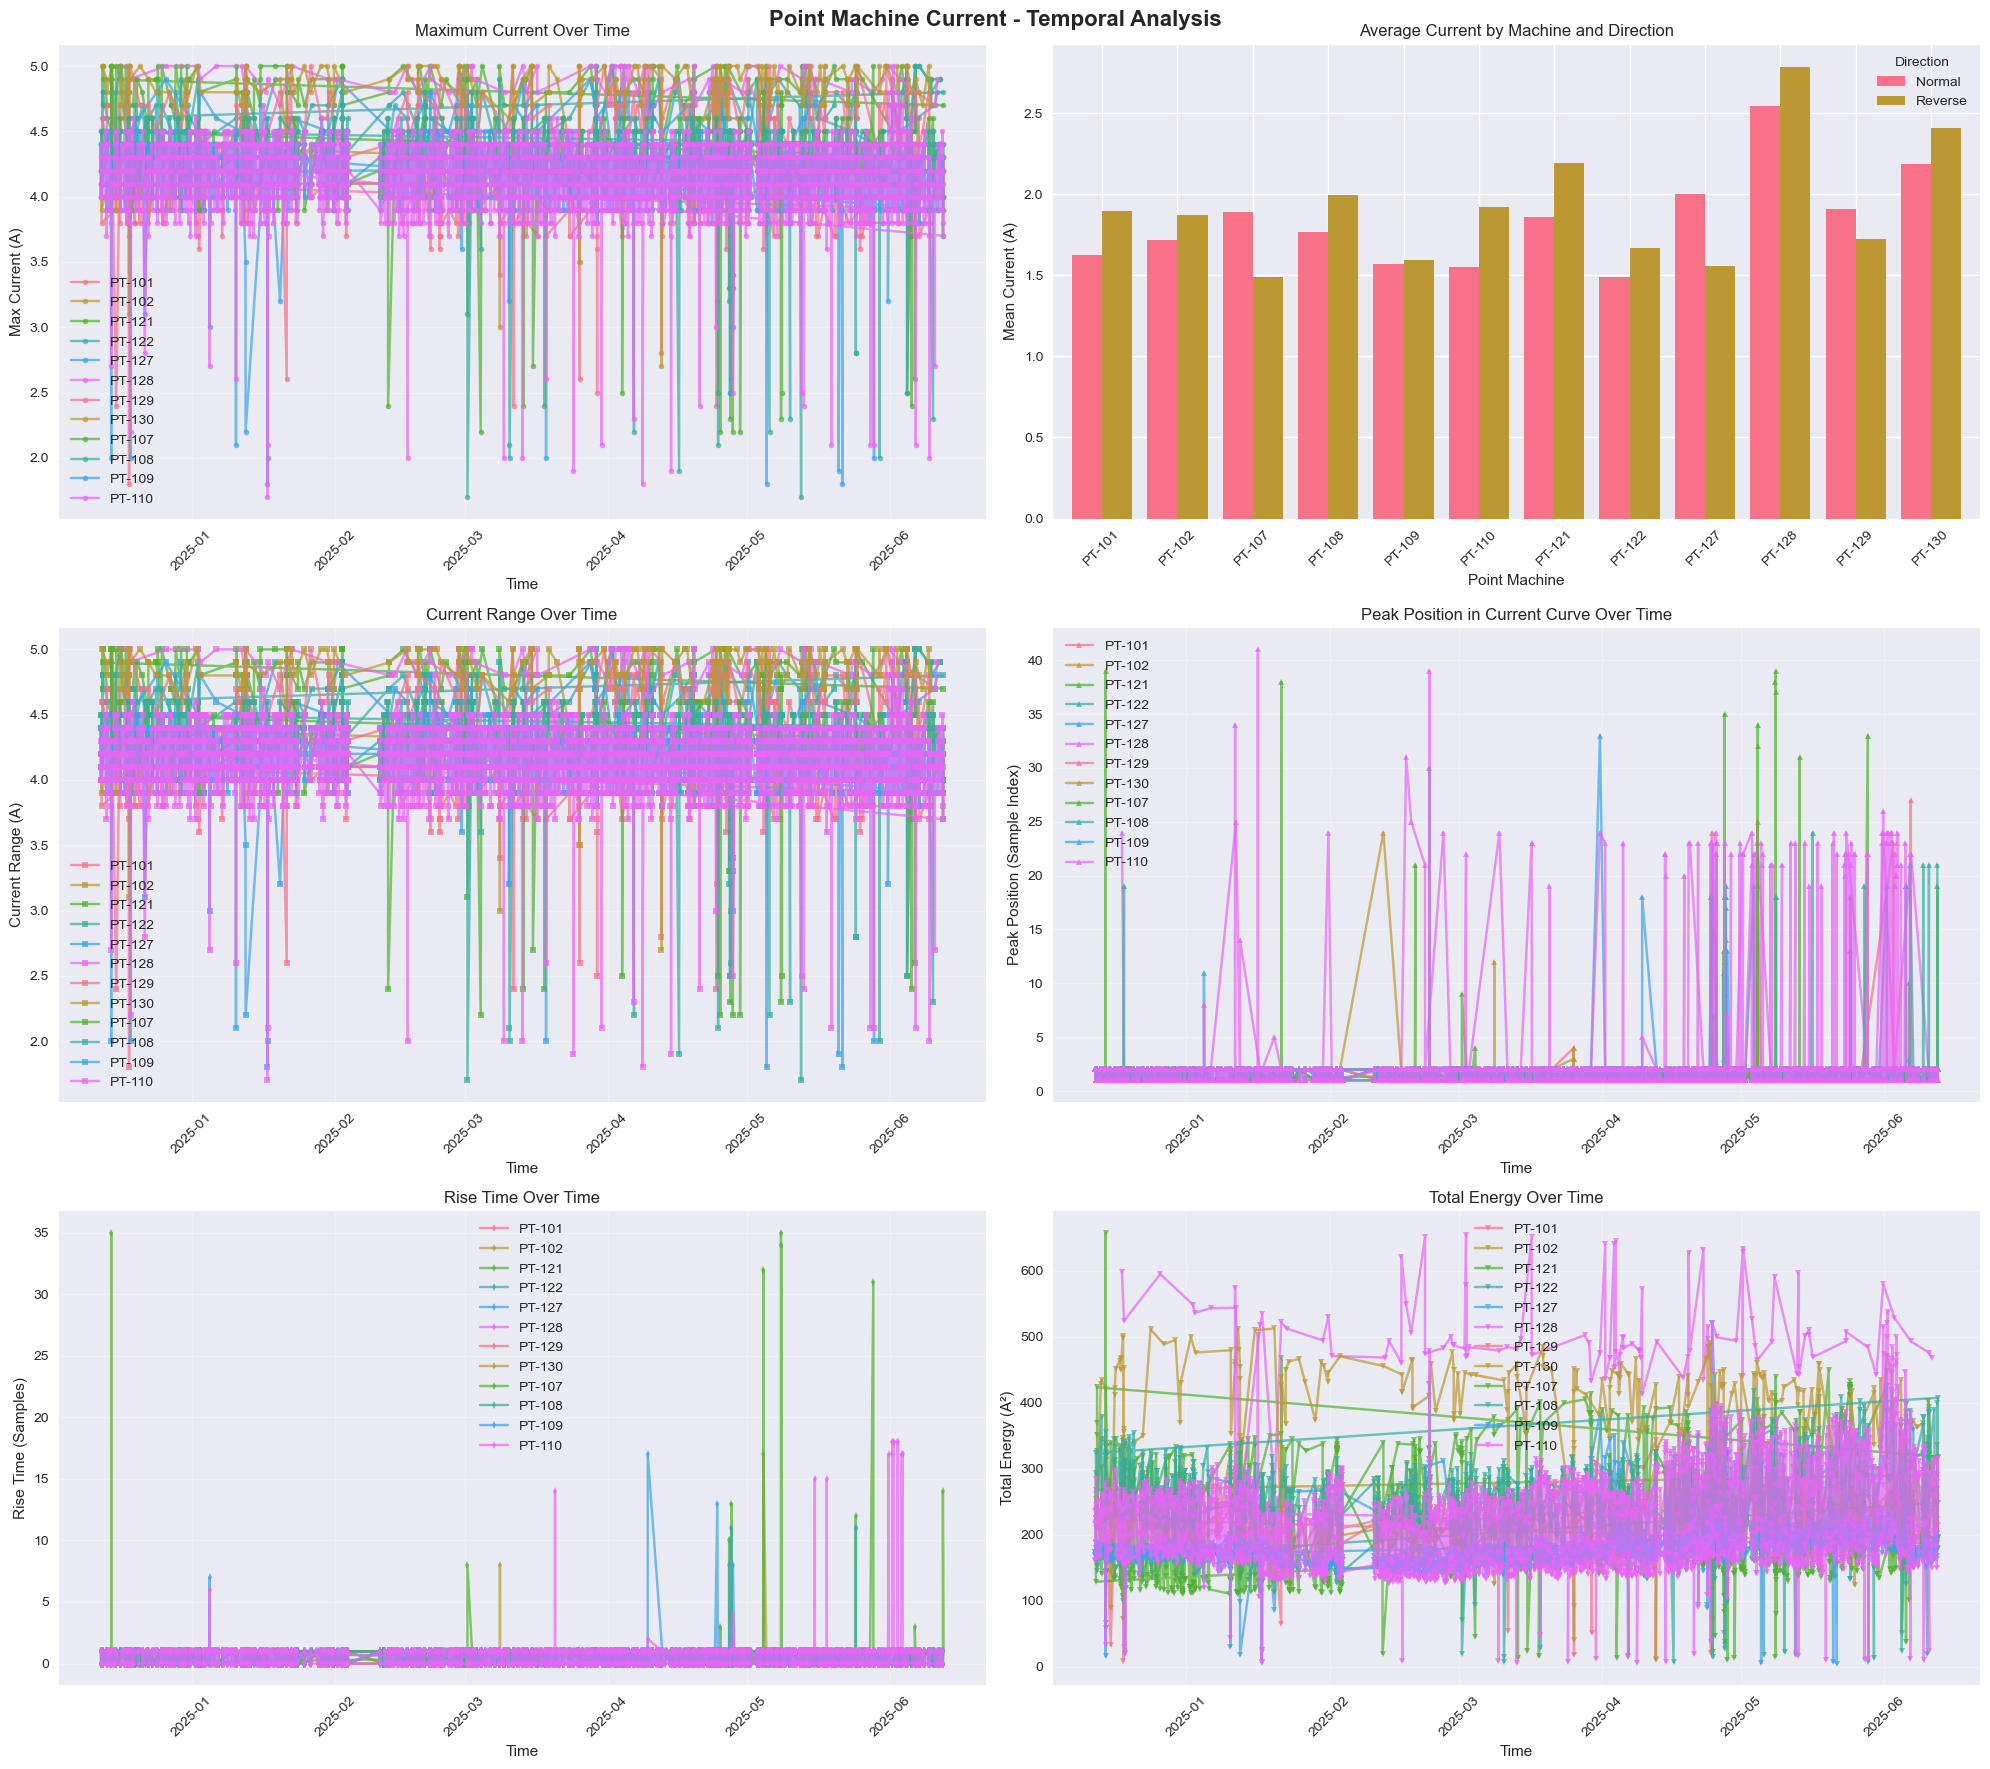

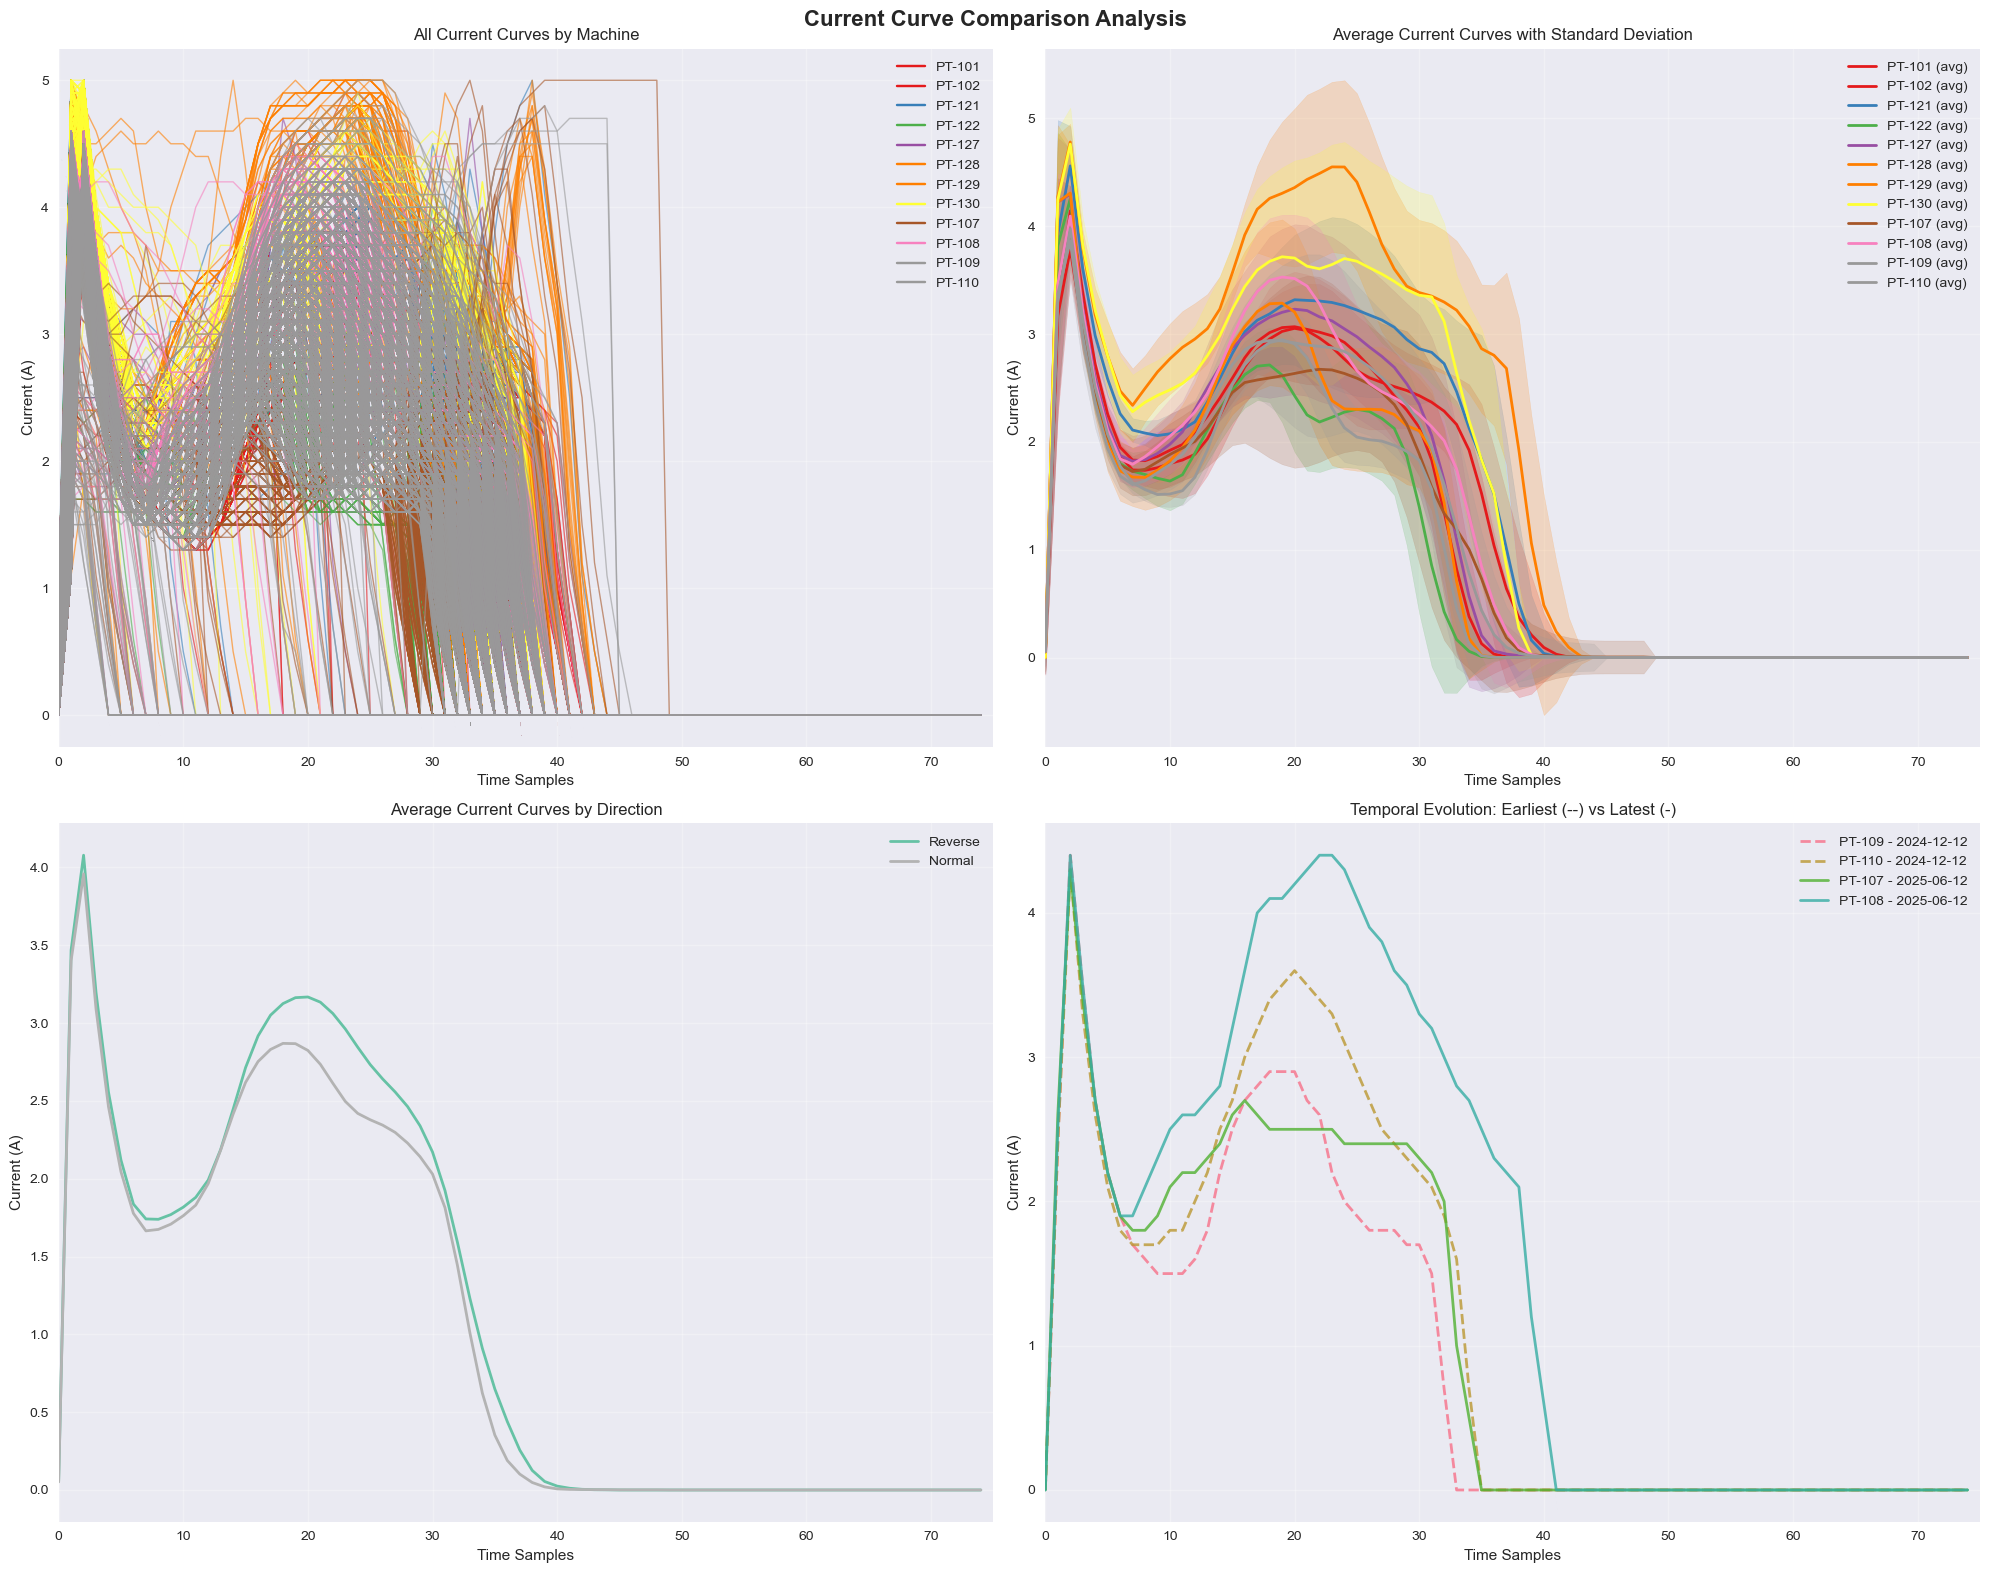

Analysis completed with curve length normalized to 75 samples
=== POINT MACHINE CURRENT ANALYSIS REPORT ===

1. BASIC STATISTICS BY MACHINE:
--------------------------------------------------
              max_current                  mean_current                       \
                     mean    std  min  max         mean    std    min    max   
point_machine                                                                  
PT-101              3.953  0.178  2.4  4.4        1.770  0.211  0.202  2.662   
PT-102              4.225  0.172  3.0  4.7        1.801  0.155  0.500  2.472   
PT-107              4.243  0.289  2.2  5.0        1.693  0.292  0.118  3.408   
PT-108              4.311  0.273  1.9  4.6        1.880  0.239  0.094  2.411   
PT-109              4.169  0.204  1.8  4.5        1.580  0.109  0.077  2.154   
PT-110              4.144  0.270  1.7  5.0        1.738  0.269  0.081  3.367   
PT-121              4.790  0.234  2.5  5.0        2.072  0.201  0.939  2.430   
PT-122  

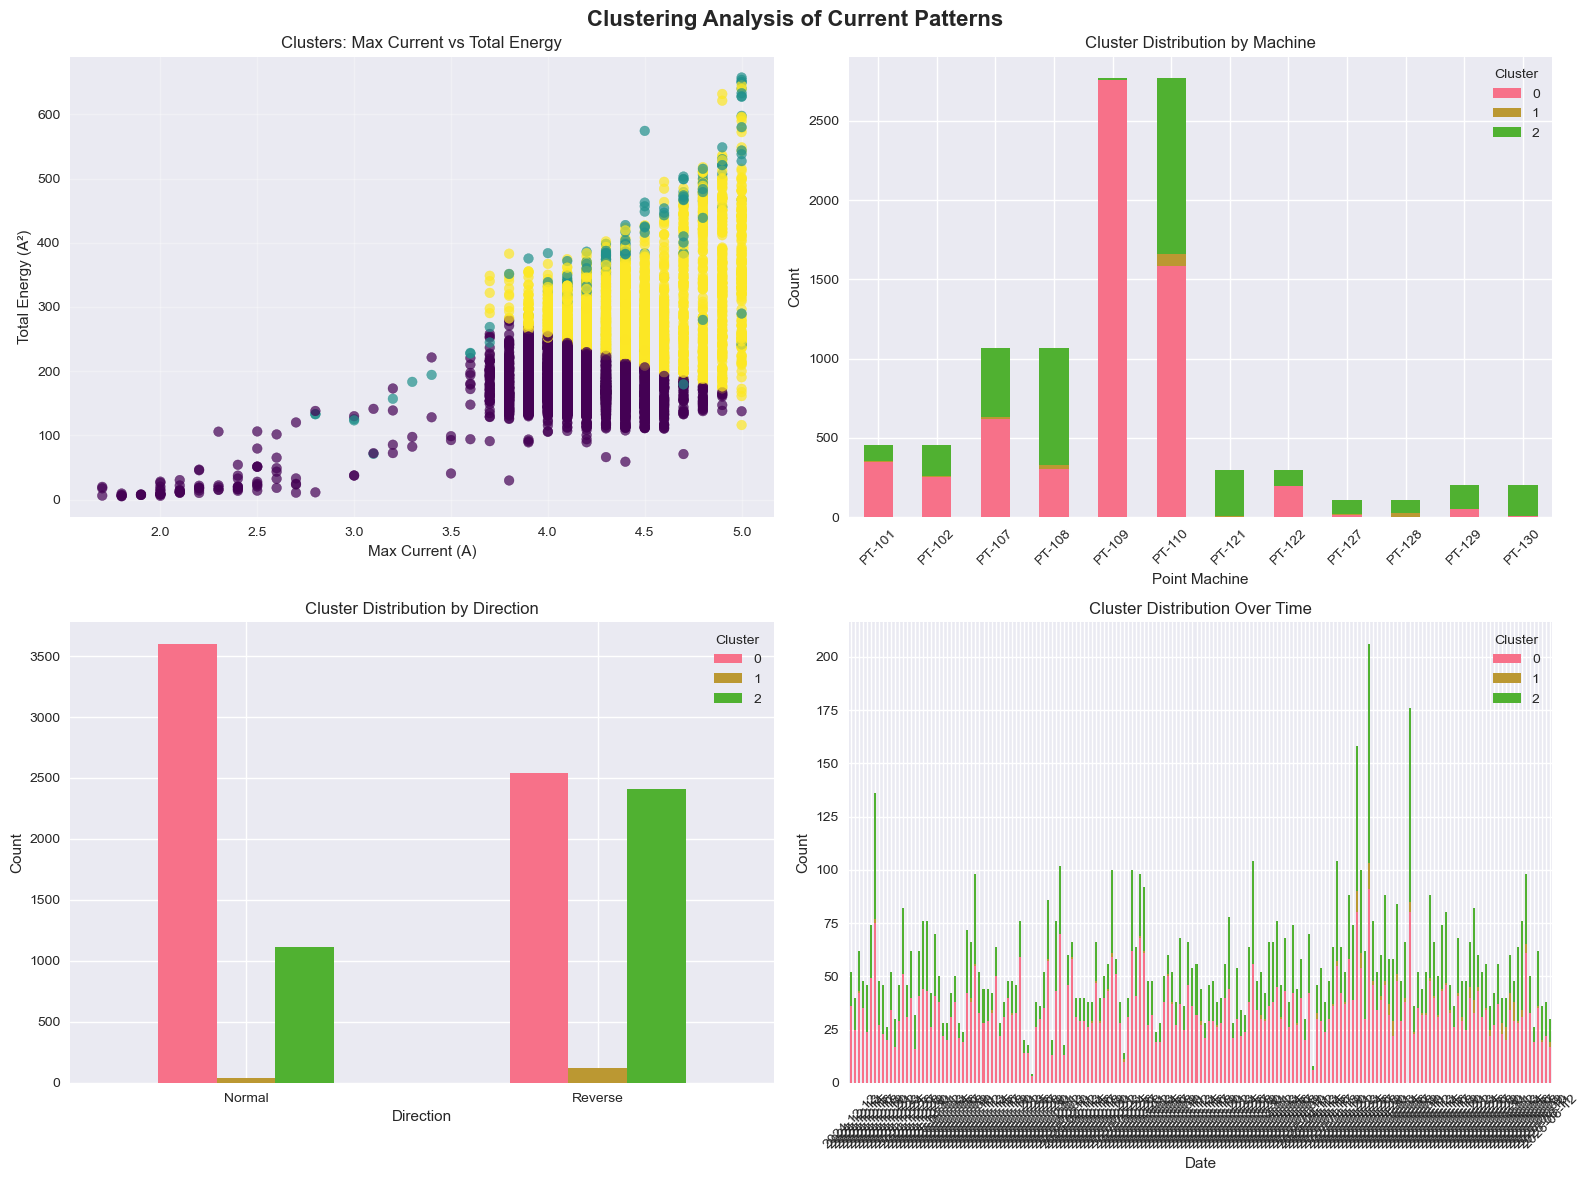


5. CLUSTER ANALYSIS:
-------------------------

Cluster 0 (6136 samples):
  Avg Max Current: 4.14 A
  Avg Total Energy: 177.04 A²
  Machines: ['PT-101', 'PT-102', 'PT-122', 'PT-121', 'PT-127', 'PT-129', 'PT-130', 'PT-107', 'PT-108', 'PT-109', 'PT-110']
  Directions: ['Normal', 'Reverse']

Cluster 1 (162 samples):
  Avg Max Current: 4.37 A
  Avg Total Energy: 391.35 A²
  Machines: ['PT-102', 'PT-101', 'PT-121', 'PT-122', 'PT-128', 'PT-127', 'PT-130', 'PT-108', 'PT-107', 'PT-110', 'PT-109']
  Directions: ['Normal', 'Reverse']

Cluster 2 (3518 samples):
  Avg Max Current: 4.42 A
  Avg Total Energy: 288.31 A²
  Machines: ['PT-101', 'PT-102', 'PT-121', 'PT-122', 'PT-127', 'PT-128', 'PT-129', 'PT-130', 'PT-108', 'PT-107', 'PT-110', 'PT-109']
  Directions: ['Reverse', 'Normal']

KEY INSIGHTS AND RECOMMENDATIONS

1. MACHINE PERFORMANCE COMPARISON:
              max_current        total_energy         rise_time
                     mean    std         mean     std      mean
point_machine      

In [4]:
if __name__ == "__main__":
    # Replace 'your_data_file.csv' with the path to your actual data file
    analyzer = main()